# Evaluation harness and baselines

Before any model is trained, we need two things: a **fair way to test it**, and **the bars it has to clear**. This notebook sets up both on the real data, using the code in `src/oa_market_intelligence/modeling/` (tested separately; see `docs/evaluation_protocol.md`).

**The question this notebook answers:** if a model has to predict next month's Up / Down / Flat for Zilretta's visit share, how well does a *no-effort guess* do? Any real model must beat that.

Plain-language terms used below:

- **Walk-forward test:** train on the months up to *t*, predict month *t*, then add month *t* to the training data and repeat. The model never sees the future, exactly as in real monthly use.
- **Persistence baseline:** guess that next month's direction repeats last month's.
- **Always-majority baseline:** always guess the most common label (Flat).
- **Recall on Down:** of the months that really were Down, how many did we catch? This is the project's priority metric (PROPOSAL §17.2), because a falling share is what the brand manager most needs to know about.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

from oa_market_intelligence.features.monthly import (
    compute_monthly_features, load_monthly_gold, model_ready_monthly)
from oa_market_intelligence.modeling.baselines import MajorityClassBaseline, PersistenceBaseline
from oa_market_intelligence.modeling.evaluation import (
    CLASSES, DEFAULT_MIN_TRAIN, compare_models, confusion, mcnemar_exact, score_table)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)

engine = create_engine("sqlite:///../data/processed/warehouse.db")
gold = load_monthly_gold(engine)
features = compute_monthly_features(gold)
ready = model_ready_monthly(features)

BASELINES = {"always-majority": MajorityClassBaseline, "persistence": PersistenceBaseline}
print(f"{len(gold)} months in Gold; {len(ready)} are model-ready "
      f"({ready.index[0]} to {ready.index[-1]}); {ready.shape[1] - 1} features")

72 months in Gold; 59 are model-ready (202009 to 202507); 22 features


## 1. How the test is laid out

Only **59 of the 72 months** can be used. The first 13 have no label yet, because the label needs 12 months of past volatility plus one difference. Of those 59, the first **24** are used only for initial training (two full seasonal cycles, PROPOSAL §18.3). That leaves **35 months** to be predicted one at a time.

The proposal assumed about 48 test months. With 13 months consumed by the label's warm-up, 35 is the real number. That matters for how much we can conclude, as section 5 shows.

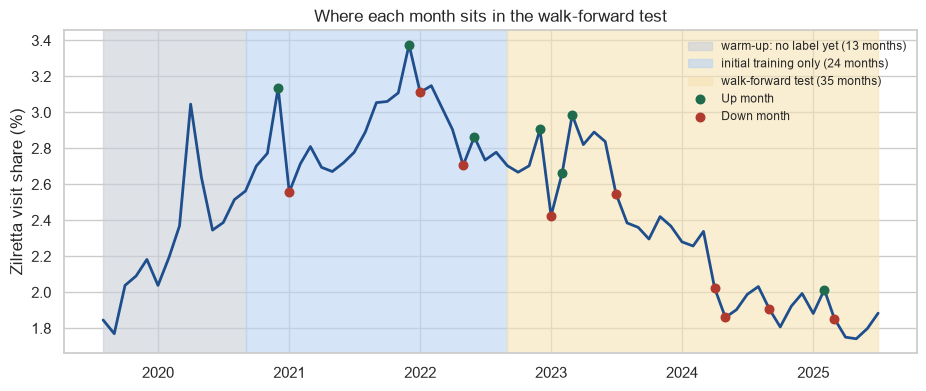

In [2]:
dates = pd.to_datetime(gold["month_id"].astype(str), format="%Y%m")
share = gold["visit_share"] * 100
first_ready = dates[gold["month_id"] == ready.index[0]].iloc[0]
first_test = dates[gold["month_id"] == ready.index[DEFAULT_MIN_TRAIN]].iloc[0]

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(dates, share, color="#1F4E8C", lw=2)
ax.axvspan(dates.iloc[0], first_ready, color="#C9CFD8", alpha=0.6, label="warm-up: no label yet (13 months)")
ax.axvspan(first_ready, first_test, color="#BBD3F2", alpha=0.6, label="initial training only (24 months)")
ax.axvspan(first_test, dates.iloc[-1], color="#F6E3B4", alpha=0.6, label="walk-forward test (35 months)")
labels = features["direction_label"].reindex(gold["month_id"].values).to_numpy()
for cls, color in [("Up", "#1F6B4D"), ("Down", "#B03A2E")]:
    mask = labels == cls
    ax.scatter(dates[mask], share[mask], color=color, s=38, zorder=3, label=f"{cls} month")
ax.set_ylabel("Zilretta visit share (%)")
ax.set_title("Where each month sits in the walk-forward test")
ax.legend(loc="upper right", fontsize=8.5, frameon=False)
plt.show()

## 2. What a model is up against

In the 35 test months most months are Flat. A model that is lazy and always says Flat will look decent on plain accuracy while being useless to the brand manager.

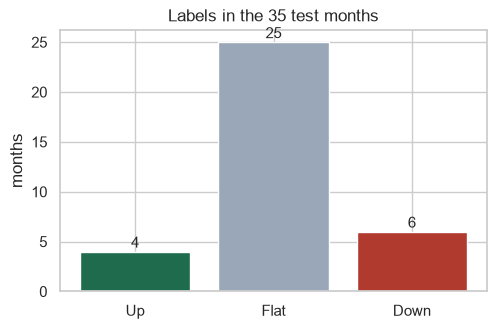

Always saying Flat is right 71.4% of the time, and catches 6 Down months: none of them.


In [3]:
predictions = compare_models(ready, BASELINES, min_train=DEFAULT_MIN_TRAIN)
truth = predictions["y_true"].value_counts().reindex(CLASSES)

fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.bar(truth.index, truth.values, color=["#1F6B4D", "#9AA7B8", "#B03A2E"])
for x, v in enumerate(truth.values):
    ax.text(x, v + 0.4, str(v), ha="center", fontsize=11)
ax.set_title(f"Labels in the {len(predictions)} test months")
ax.set_ylabel("months")
plt.show()
print(f"Always saying Flat is right {truth['Flat'] / truth.sum():.1%} of the time, "
      f"and catches {int(truth['Down'])} Down months: none of them.")

## 3. The two baselines, scored

Reading the table: `accuracy` is the share of months called correctly. `balanced_accuracy` averages recall across the classes that occur, so a lazy model can't hide. `recall_down` is the priority metric. `precision_down` is how often a Down call was right.

In [4]:
cols = ["n", "accuracy", "balanced_accuracy", "macro_f1", "precision_down", "recall_down", "recall_up"]
scores = score_table(predictions)[cols]
scores["n"] = scores["n"].astype(int)
scores.round(3)

,n,accuracy,balanced_accuracy,macro_f1,precision_down,recall_down,recall_up
always-majority,35,0.714,0.333,0.278,0.000,0.000,0.00
persistence,35,0.629,0.406,0.406,0.167,0.167,0.25


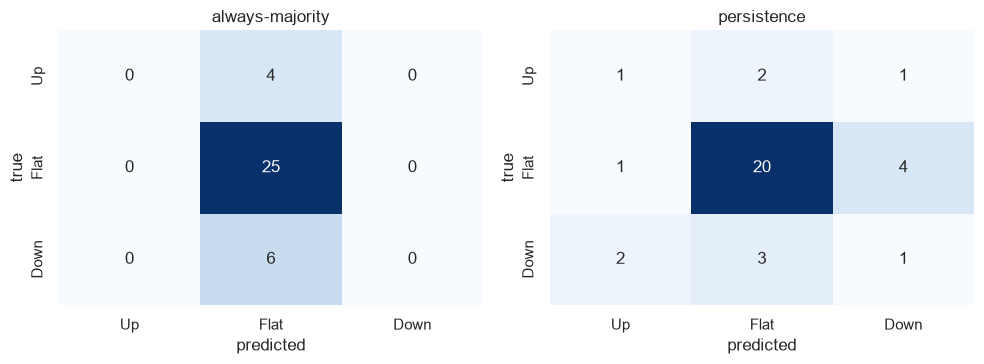

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, name in zip(axes, BASELINES):
    sns.heatmap(confusion(predictions["y_true"], predictions[name]), annot=True, fmt="d", cbar=False,
                cmap="Blues", ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

**Reading the results.**

- **Always-majority** scores the best plain accuracy and the worst on everything that matters: it never calls an Up or a Down.
- **Persistence** catches 1 of the 6 Down months, which is about the share of Down months in the test window (6 of 35). That is no better than guessing. The reason is that the label measures a *surprise* relative to recent volatility. A surprise rarely repeats the following month, so "same as last month" is a weak guess for direction, even though it is a strong guess for the share *level*.

So the bar is low on direction: any model that finds even a few Down months without too many false alarms would be doing real work. The harder question is whether 35 months can prove it (section 5).

## 4. Does the result depend on where the test starts?

The 24-month starting window is the proposal's choice. Here is the same comparison with a shorter (18) and longer (30) starting window.

In [6]:
rows = []
for min_train in (18, 24, 30):
    pred = compare_models(ready, BASELINES, min_train=min_train)
    s = score_table(pred)
    counts = pred["y_true"].value_counts().reindex(CLASSES).fillna(0).astype(int)
    for name in BASELINES:
        rows.append({"start window": min_train, "test months": len(pred), "Down months": counts["Down"],
                     "baseline": name, "accuracy": s.loc[name, "accuracy"],
                     "recall_down": s.loc[name, "recall_down"], "recall_up": s.loc[name, "recall_up"]})
pd.DataFrame(rows).round(3).set_index(["start window", "test months", "Down months", "baseline"])

accuracy  recall_down  recall_up
start window test months Down months baseline                                         
18           41          7           always-majority     0.707        0.000       0.00
                                     persistence         0.610        0.143       0.20
24           35          6           always-majority     0.714        0.000       0.00
                                     persistence         0.629        0.167       0.25
30           29          5           always-majority     0.759        0.000       0.00
                                     persistence         0.655        0.200       0.50

The picture is the same at every start: always-Flat never catches a Down month, and persistence catches a Down month about as often as chance. The conclusion does not hinge on the 24-month choice.

## 5. How much can 35 months prove?

McNemar's test (PROPOSAL §18.4) compares two classifiers on the same months by looking only at the months where exactly one of them is right. If they are equally good, those months split about 50/50. The table shows the p-value for each possible split.

In [7]:
grid = pd.DataFrame(
    {b: {a: mcnemar_exact(["Flat"] * (a + b), (["Flat"] * a) + (["Up"] * b), (["Up"] * a) + (["Flat"] * b))["p_value"]
         for a in range(0, 11)} for b in range(0, 6)})
grid.index.name = "months only model A is right"
grid.columns.name = "months only model B is right"
grid.round(3).style.background_gradient(cmap="Greens_r", vmin=0, vmax=0.2).format("{:.3f}")

months only model B is right,0,1,2,3,4,5
months only model A is right,,,,,,
0,1.000,1.000,0.500,0.250,0.125,0.062
1,1.000,1.000,1.000,0.625,0.375,0.219
2,0.500,1.000,1.000,1.000,0.688,0.453
3,0.250,0.625,1.000,1.000,1.000,0.727
4,0.125,0.375,0.688,1.000,1.000,1.000
5,0.062,0.219,0.453,0.727,1.000,1.000
6,0.031,0.125,0.289,0.508,0.754,1.000
7,0.016,0.070,0.180,0.344,0.549,0.774
8,0.008,0.039,0.109,0.227,0.388,0.581


In [8]:
for label, cls in [("3-class correctness", None), ("Down vs. rest (priority class)", "Down")]:
    r = mcnemar_exact(predictions["y_true"], predictions["always-majority"], predictions["persistence"],
                      positive_class=cls)
    print(f"majority vs persistence, {label}: only-majority-right={r['a_only_correct']}, "
          f"only-persistence-right={r['b_only_correct']}, p={r['p_value']:.3f}")

majority vs persistence, 3-class correctness: only-majority-right=5, only-persistence-right=2, p=0.453
majority vs persistence, Down vs. rest (priority class): only-majority-right=5, only-persistence-right=1, p=0.219


**What this means.** With only 6 Down months in the test window, a model has to be right on several months where the baseline is wrong, and almost never wrong where the baseline is right, to reach p < 0.05 (the green cells above, such as 6 versus 0). A modest real improvement can easily look "not significant" here.

So the plan for the models is:

1. Report the **size of the improvement** (recall on Down, balanced accuracy, macro-F1) next to the p-value, not the p-value alone.
2. Treat "no significant difference" as a legitimate, expected finding, as the proposal anticipated (§18.4).
3. Prefer simple, regularized models, because 59 months cannot support complex ones.

## Takeaways

| | Always-majority | Persistence |
|---|---|---|
| Test months | 35 (25 Flat, 6 Down, 4 Up) | same |
| Accuracy | 71.4% | 62.9% |
| Recall on Down | 0 of 6 | 1 of 6 |
| Recall on Up | 0 of 4 | 1 of 4 |

- A trained model has to beat **recall on Down of 1 of 6** and **balanced accuracy of 0.41** to say it adds something.
- Plain accuracy is the wrong yardstick here: the lazy model wins it.
- The harness itself is guarded by tests, including one that rewrites every later month and checks that month *t*'s prediction does not change.